In [5]:
from ggner_3d import plotting
plotting.update_rcparams()

import seaborn as sns
import matplotlib.pyplot as plt

COLORS = plotting.COLORS

import pandas as pd

In [6]:
label_dict = {
    'XPF': 'GG-NER',
    'KAT5': 'NER Regulator',
    'RAD21': 'Genome Architecture',
    'TFIIH4': 'GG-NER',
    'WAPL': 'Genome Architecture',
    'CUL4B': 'GG-NER',
    'KAT7': 'NER Regulator',
    'STAG2': 'Genome Architecture',
    'SMC3': 'Genome Architecture',
    'TFIIH1': 'GG-NER',
    'RFA2': 'GG-NER',
    'MMS19': 'NER Regulator',
    'RFA4': 'GG-NER',
    'SIR1': 'NER Regulator',
    'DDB1': 'GG-NER',
    'XPC': 'GG-NER',
    'STAG1': 'Genome Architecture',
    'DDA1': 'GG-NER',
    'PDS5B': 'Genome Architecture',
    'TFIIH3': 'GG-NER',
    'XPB': 'GG-NER',
    'RAD23B': 'GG-NER',
    'ERCC1': 'GG-NER',
    'RFA3': 'GG-NER',
    'SCC4': 'Genome Architecture',
    'SMC1A': 'Genome Architecture',
    'TFIIH2': 'GG-NER',
    'TFIIH2L': 'GG-NER',
    'RFA1': 'GG-NER',
    'CUL4A': 'GG-NER',
    'ATX3': 'NER Regulator',
    'XPA': 'GG-NER',
    'RAD23A': 'GG-NER',
    'NIPBL': 'Genome Architecture',
    'RBX1': 'GG-NER',
    'PDS5A': 'Genome Architecture',
    'XPG': 'GG-NER',
    'DDB2': 'GG-NER',
    'XPD': 'GG-NER',
    'UBP45': 'NER Regulator',
    'CDCA5': 'Genome Architecture',
    'UBP44': 'NER Regulator',
    'TFIIH5': 'GG-NER',
    'CETN2': 'GG-NER',
    'CTCF': 'Genome Architecture'
}

In [7]:
plot_df = pd.read_csv("/home/carlos/Clone/ggner-3d/phace_index_df.csv")

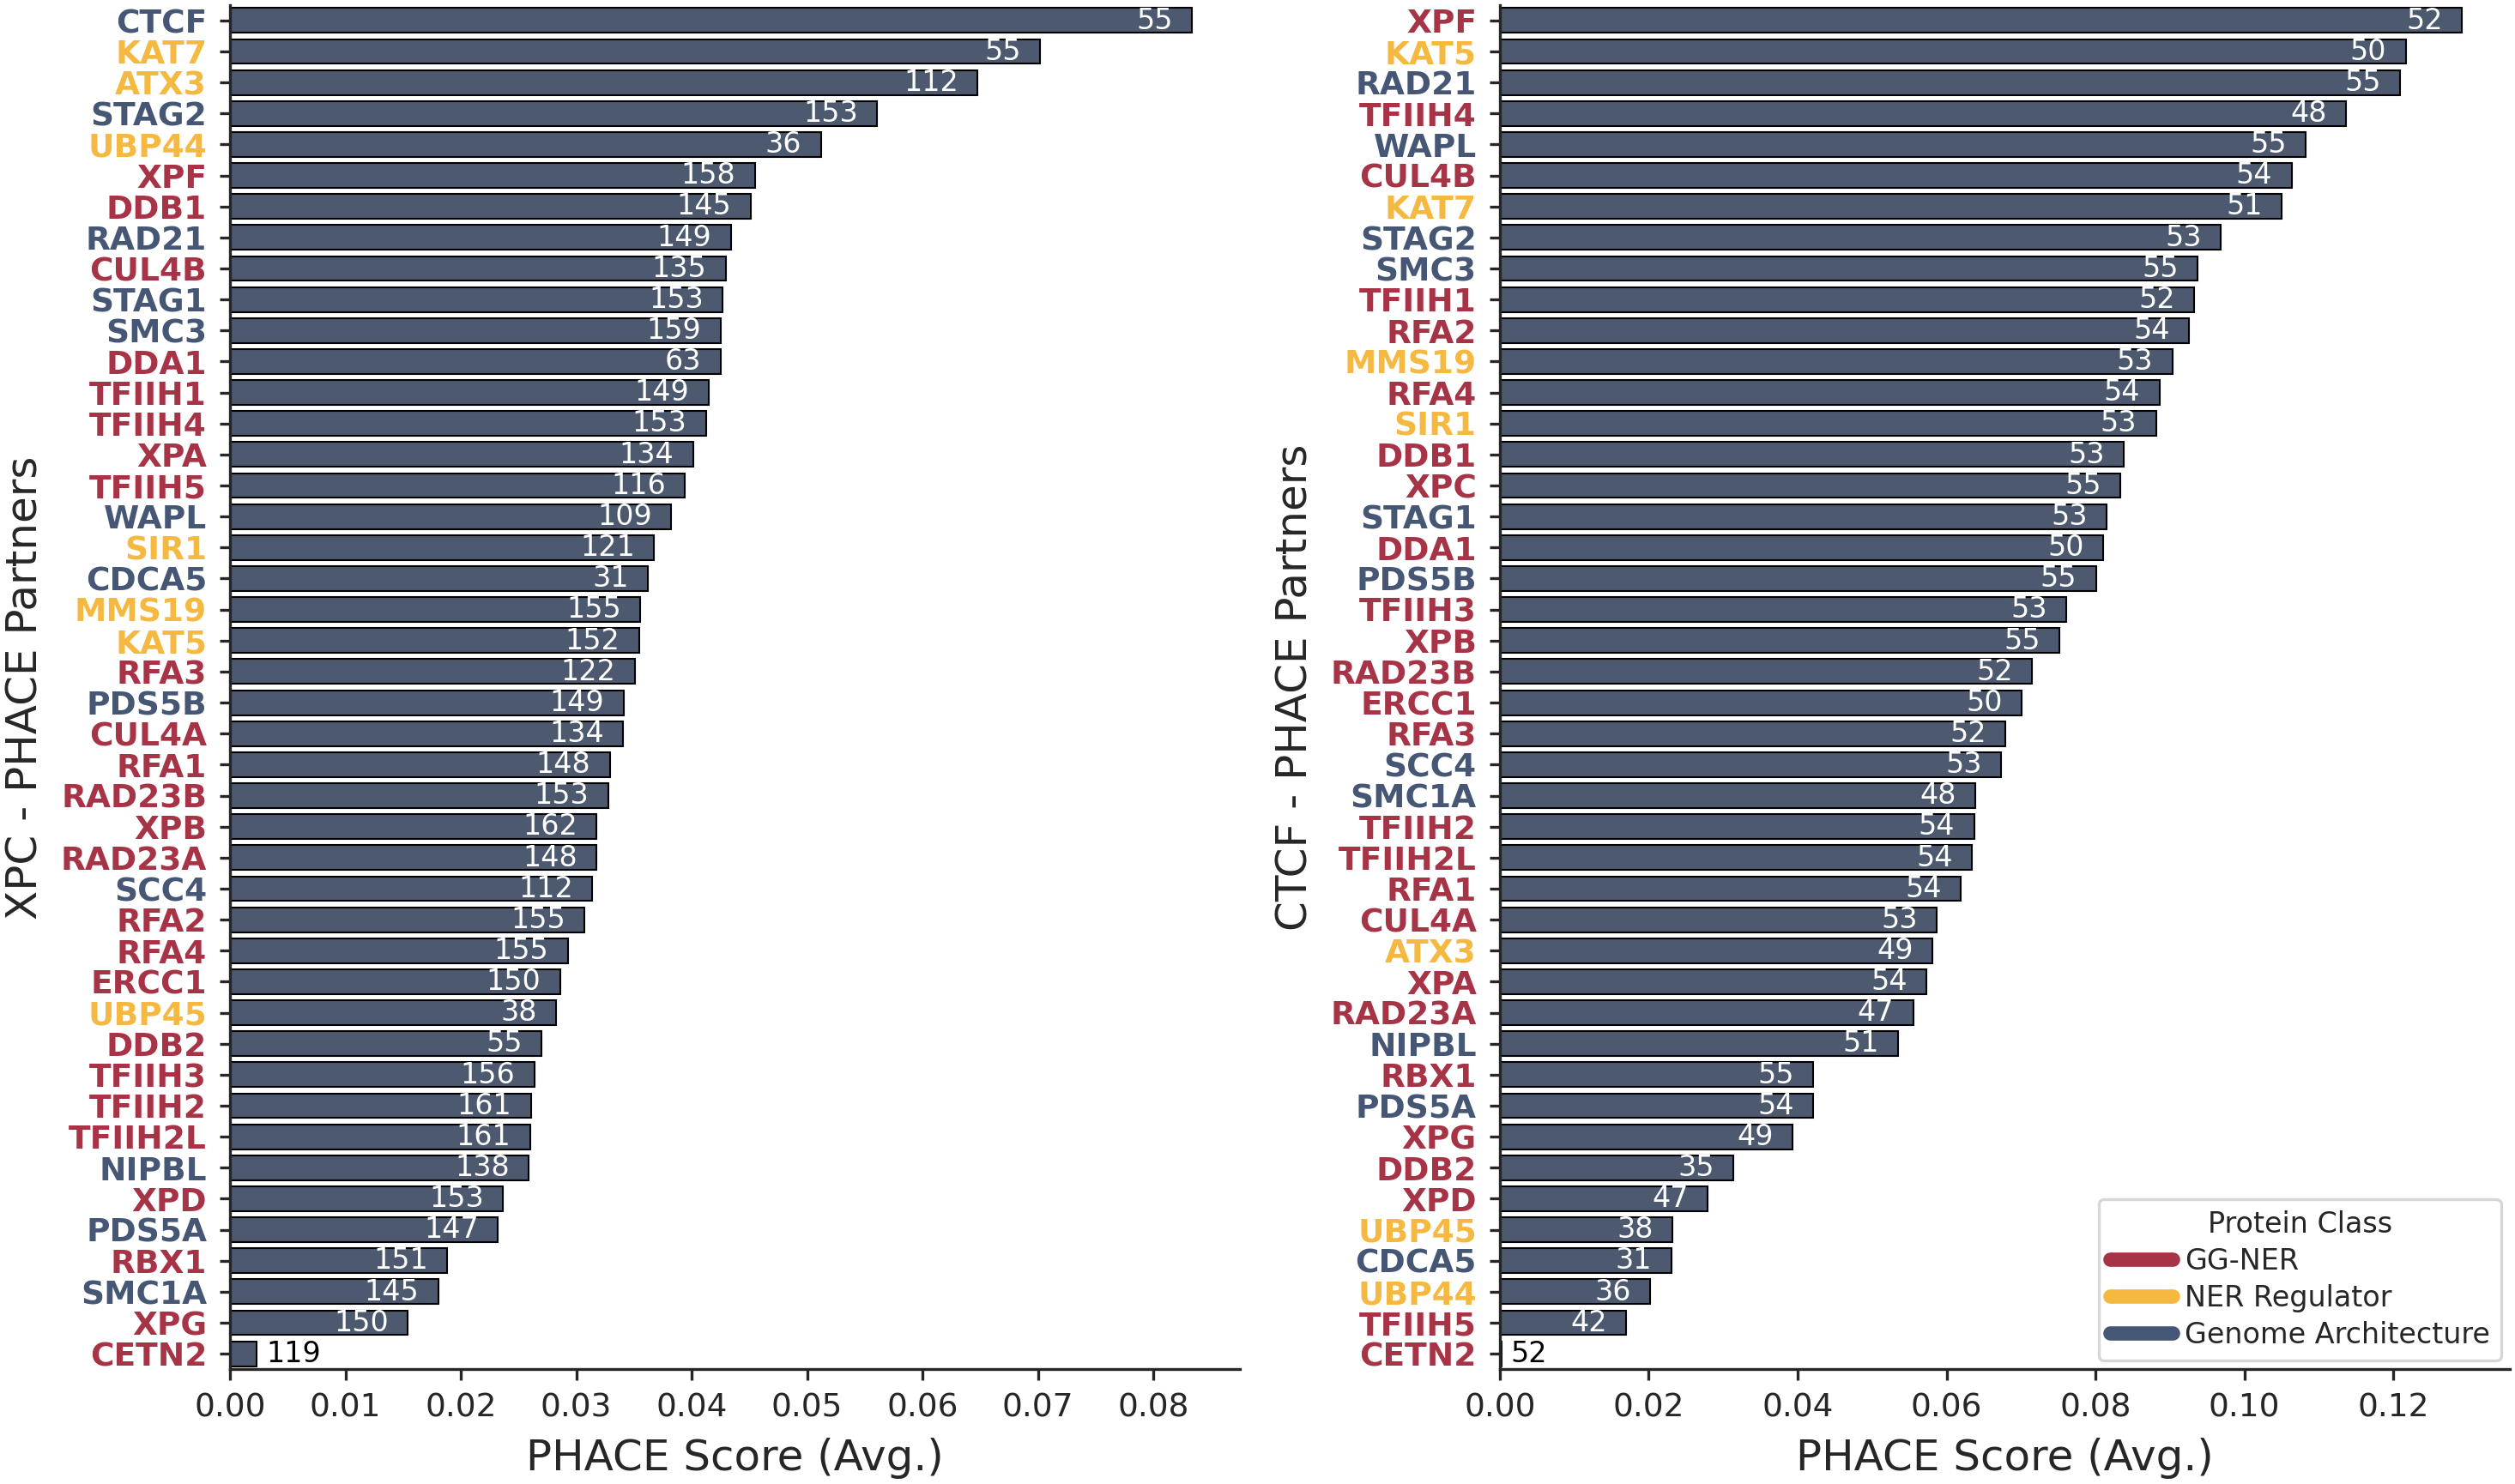

In [8]:

plot_df["class"] = plot_df["partner_label"].map(label_dict)

xpc_subset = plot_df.loc[plot_df["row_label"] == "XPC"].copy().sort_values("score", ascending=False)
ctcf_subset = plot_df.loc[plot_df["row_label"] == "CTCF"].copy().sort_values("score", ascending=False)

class_colors = {
    "GG-NER": COLORS[1],
    "NER Regulator": COLORS[2],
    "Genome Architecture": COLORS[0],
}

bar_color = '#465775ff'

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

sns.barplot(
    data=xpc_subset,
    x="score",
    y="partner_label",
    ax=ax[0],
    edgecolor="black",
    linewidth=0.5,
    color=bar_color
)

sns.barplot(
    data=ctcf_subset,
    x="score",
    y="partner_label",
    ax=ax[1],
    edgecolor="black",
    linewidth=0.5,
    color=bar_color
)

# color y tick labels by class
for this_ax, subset in zip(ax, [xpc_subset, ctcf_subset]):
    tick_to_class = subset.set_index("partner_label")["class"].to_dict()

    for tick in this_ax.get_yticklabels():
        partner = tick.get_text()
        tick.set_color(class_colors.get(tick_to_class.get(partner), "black"))
        tick.set_fontweight("bold")

# set x and y labels
ax[0].set_xlabel("PHACE Score (Avg.)")
ax[0].set_ylabel("XPC - PHACE Partners")
ax[1].set_xlabel("PHACE Score (Avg.)")
ax[1].set_ylabel("CTCF - PHACE Partners")

# add legend
handles = [plt.Line2D([0], [0], color=color, lw=4, label=label) for label, color in class_colors.items()]
ax[1].legend(handles=handles, title="Protein Class", loc="lower right")

# write n species on bars
for this_ax, subset in zip(ax, [xpc_subset, ctcf_subset]):
    xmax = subset["score"].max()
    inset = xmax * 0.02
    outset = xmax * 0.01

    for patch, n in zip(this_ax.patches, subset["speciesCount"]):
        width = patch.get_width()
        y = patch.get_y() + patch.get_height() / 2

        if width > xmax * 0.12:
            x = width - inset
            ha = "right"
            color = "white"
        else:
            x = width + outset
            ha = "left"
            color = "black"

        this_ax.text(
            x, y, f"{int(n)}",
            va="center", ha=ha,
            color=color, fontsize=8
        )

sns.despine()
plt.tight_layout()

fig.savefig("/home/carlos/Clone/ggner-3d/figs/fig4/phace_index.svg")